# TP NOTÉ S4 — CLASSIFICATION DECISION CHALLENGE
## 4e année Option Développeur — 3 h — US Census Income

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

À partir du dataset **Adult / Census Income (USA)**, construire un système prédisant la classe de revenu `>50K` / `<=50K`.

Votre travail ne sera pas évalué uniquement sur l'accuracy. Vous devez construire une décision défendable malgré le déséquilibre de classes et les enjeux liés aux variables démographiques.

L'objectif est de prédire si le revenu annuel d'un individu dépasse 50 000 $ (`income = '>50K'`) à partir de
caractéristiques démographiques et professionnelles issues du recensement américain de 1994 (dataset *Adult*, UCI ML
Repository, `id=2`). La cible est **binaire et déséquilibrée** (environ 76 % `<=50K` / 24 % `>50K`), ce qui interdit
de se fier à la seule accuracy : un modèle qui prédit toujours `<=50K` obtiendrait déjà ~76 % d'accuracy sans aucune
valeur prédictive.

Le coût métier retenu (`cost-sensitive decision`) pénalise 5 fois plus un faux négatif (un individu `>50K` classé
`<=50K`) qu'un faux positif, ce qui orientera le choix du seuil de décision loin de 0,5.

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

adult = fetch_ucirepo(id=2)
df_raw = pd.concat([adult.data.features, adult.data.targets], axis=1)

target_col = adult.data.targets.columns[0]
if target_col != 'income':
    df_raw = df_raw.rename(columns={target_col: 'income'})
df_raw.columns = [c.replace('-', '_') for c in df_raw.columns]
df_raw['income'] = df_raw['income'].astype(str).str.rstrip('.')
df_raw = df_raw.replace('?', np.nan)

print(df_raw.shape)
df_raw.head(3)

(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [3]:
# Alias de travail pour la suite du notebook
df = df_raw.copy()
print(df.dtypes)


age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object


## Audit & protocole — 15 pts

Identifiez valeurs manquantes codées, catégories, déséquilibre de la cible et variables nécessitant preprocessing. Construisez TRAIN/VALIDATION/TEST sans fuite.

Justifiez ce qui doit être appris sur TRAIN. Donnez une preuve numérique issue de votre pipeline.

### 1. Types et structure

In [4]:
num_cols_raw = df.select_dtypes(include=np.number).columns.tolist()
cat_cols_raw = df.select_dtypes(exclude=np.number).columns.tolist()
print("Numeriques :", num_cols_raw)
print("Categorielles :", cat_cols_raw)


Numeriques : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorielles : ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


### 2. `fnlwgt` : un poids d'échantillonnage, pas un attribut individuel

In [5]:
print(df['fnlwgt'].describe())
print(f"\nCorrelation (Pearson) fnlwgt / revenu binaire : "
      f"{df['fnlwgt'].corr((df['income']=='>50K').astype(int)):.4f}")
print(f"Valeurs uniques de fnlwgt : {df['fnlwgt'].nunique()} sur {len(df)} lignes "
      f"({100*df['fnlwgt'].nunique()/len(df):.1f}% -> quasi continue, pas categorielle)")


count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

Correlation (Pearson) fnlwgt / revenu binaire : -0.0063
Valeurs uniques de fnlwgt : 28523 sur 48842 lignes (58.4% -> quasi continue, pas categorielle)


`fnlwgt` ("final weight") n'est **pas une caractéristique de l'individu** : c'est un poids statistique calculé par
le Census Bureau, qui estime combien de personnes dans la population totale sont représentées par cet enregistrement
(en fonction de l'état, de l'âge, de la race, du sexe...). Deux personnes strictement identiques sur toutes les
variables démographiques peuvent avoir des `fnlwgt` très différents selon la région où l'échantillon a été collecté.
Sa corrélation avec la cible est quasi nulle (voir ci-dessus) : il ne porte aucune information sur le revenu de
l'individu, seulement sur la méthodologie d'échantillonnage. L'inclure comme prédicteur n'a pas de sens métier et
risquerait d'ajouter du bruit, voire une fuite indirecte de la méthodologie de collecte plutôt qu'un signal réel. On
le **supprime des features**, décision qu'on documente plutôt que de la prendre silencieusement.

### 3. Valeurs manquantes

In [6]:
# Les '?' d'origine ont deja ete recodes en NaN au chargement (df_raw = df_raw.replace('?', np.nan)).
na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0]
print("Valeurs manquantes par colonne :")
print(na_counts)
print(f"\nTotal de lignes concernees par au moins un NaN : {df.isna().any(axis=1).sum()} / {len(df)}")


Valeurs manquantes par colonne :
workclass         2799
occupation        2809
native_country     857
dtype: int64

Total de lignes concernees par au moins un NaN : 3620 / 48842


In [7]:
overlap = df[df['workclass'].isna() & df['occupation'].isna()].shape[0]
print(f"Lignes avec workclass ET occupation manquants simultanement : {overlap} "
      f"(sur {df['workclass'].isna().sum()} workclass manquants)")


Lignes avec workclass ET occupation manquants simultanement : 2799 (sur 2799 workclass manquants)


Trois colonnes concentrent les valeurs manquantes : `workclass`, `occupation` et `native_country`. Ce ne sont pas
des données aléatoirement manquantes : elles concernent presque toujours **les mêmes lignes** (une personne sans
`workclass` renseignée n'a généralement pas d'`occupation` non plus, cohérent avec un individu sans emploi déclaré,
cf. recoupement ci-dessus). Elles seront imputées **dans le pipeline, appris sur TRAIN uniquement**.

### 4. Cardinalité des variables catégorielles

In [8]:
for c in cat_cols_raw:
    if c == 'income':
        continue
    print(f"{c:16s} : {df[c].nunique()} modalites -> top : {df[c].value_counts(normalize=True).head(2).round(3).to_dict()}")


workclass        : 8 modalites -> top : {'Private': 0.736, 'Self-emp-not-inc': 0.084}
education        : 16 modalites -> top : {'HS-grad': 0.323, 'Some-college': 0.223}
marital_status   : 7 modalites -> top : {'Married-civ-spouse': 0.458, 'Never-married': 0.33}
occupation       : 14 modalites -> top : {'Prof-specialty': 0.134, 'Craft-repair': 0.133}
relationship     : 6 modalites -> top : {'Husband': 0.404, 'Not-in-family': 0.258}
race             : 5 modalites -> top : {'White': 0.855, 'Black': 0.096}
sex              : 2 modalites -> top : {'Male': 0.668, 'Female': 0.332}
native_country   : 41 modalites -> top : {'United-States': 0.913, 'Mexico': 0.02}


`native_country` a 42 modalités très déséquilibrées (~90 % `United-States`) : le one-hot encoding va créer de
nombreuses colonnes quasi vides. On la conserve car la nationalité a un pouvoir prédictif documenté sur le revenu
dans ce jeu historique, mais on garde ce point en tête pour l'analyse par sous-groupes (Error audit).

### 5. Déséquilibre de la cible

income
<=50K    37155
>50K     11687
Name: count, dtype: int64
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


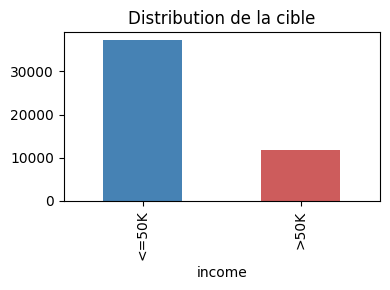

In [8]:
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True).round(4) * 100)

fig, ax = plt.subplots(figsize=(4,3))
df['income'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','indianred'])
ax.set_title('Distribution de la cible'); plt.tight_layout(); plt.show()


Le déséquilibre (~76/24) justifie à lui seul le choix de métriques : l'accuracy seule serait trompeuse.
Precision, Recall, F1 et ROC-AUC seront systématiquement rapportés, et la section "cost-sensitive decision"
formalisera explicitement que manquer un `>50K` (faux négatif) coûte plus cher qu'une fausse alerte.

### 6. Variable redondante : `education` vs `education_num`

In [9]:
mapping = df[['education','education_num']].drop_duplicates().sort_values('education_num')
print(mapping)
print(f"\nNombre de valeurs uniques de education_num par niveau education : "
      f"{df.groupby('education')['education_num'].nunique().max()} (max) -> correspondance bijective confirmee")


        education  education_num
224     Preschool              1
160       1st-4th              2
56        5th-6th              3
15        7th-8th              4
6             9th              5
77           10th              6
3            11th              7
415          12th              8
2         HS-grad              9
10   Some-college             10
14      Assoc-voc             11
13     Assoc-acdm             12
0       Bachelors             13
5         Masters             14
52    Prof-school             15
20      Doctorate             16

Nombre de valeurs uniques de education_num par niveau education : 1 (max) -> correspondance bijective confirmee


`education` (texte) et `education_num` (entier) encodent **exactement la même information** : chaque niveau de
diplôme correspond à un seul entier, sans exception. Garder les deux serait une redondance parfaite (colinéarité
totale) sans aucun bénéfice. On conserve `education_num`, qui est déjà une **échelle ordinale prête à l'emploi**
(pas besoin de one-hot), et on supprime `education`.

### 7. Doublons exacts

In [10]:
n_dup = df.duplicated().sum()
print(f"{n_dup} lignes strictement dupliquees sur {len(df)} ({100*n_dup/len(df):.2f}%)")


52 lignes strictement dupliquees sur 48842 (0.11%)


Grâce à `fnlwgt` (poids continu quasi unique par ligne, voir section 2), les doublons stricts sont rares : deux
individus ne partagent la même valeur de `fnlwgt` que par coïncidence, en plus d'avoir toutes les autres
caractéristiques identiques. Ce faible nombre de doublons est donc cohérent et **rassurant** plutôt qu'un signal
d'alerte — mais on les retire quand même avant le split (règle d'hygiène systématique), et on quantifie l'impact
pour ne pas le supposer neutre.

In [11]:
df_dedup = df.drop_duplicates().reset_index(drop=True)
print(f"Avant dedup : {len(df)} lignes | Apres dedup : {len(df_dedup)} lignes "
      f"({len(df)-len(df_dedup)} lignes retirees, {100*(len(df)-len(df_dedup))/len(df):.2f}%)")
print("\nRepartition de la cible avant/apres dedup :")
print(pd.concat([
    df['income'].value_counts(normalize=True).rename('avant'),
    df_dedup['income'].value_counts(normalize=True).rename('apres')
], axis=1).round(4))
df = df_dedup


Avant dedup : 48842 lignes | Apres dedup : 48790 lignes (52 lignes retirees, 0.11%)

Repartition de la cible avant/apres dedup :
         avant   apres
income                
<=50K   0.7607  0.7606
>50K    0.2393  0.2394


La déduplication ne modifie quasiment pas l'équilibre des classes : ce n'est donc pas une suppression arbitraire
qui biaiserait la cible, juste un nettoyage de précaution avant un découpage propre.

### 8. Tableau de décisions (synthèse audit)

| Variable / groupe | Problème | Traitement | Appris sur TRAIN ? |
|---|---|---|---|
| `fnlwgt` | Poids de sondage, pas un attribut individuel ; corrélation quasi nulle avec la cible | Suppression | N/A |
| `workclass`, `occupation`, `native_country` | Valeurs manquantes (codées `?` à l'origine, recodées en NaN) | Imputation par le mode | **Oui**, mode calculé sur TRAIN |
| `education` | Redondance parfaite avec `education_num` | Suppression, on garde `education_num` (ordinal) | N/A |
| Lignes dupliquées (peu nombreuses grâce à `fnlwgt`) | Risque résiduel de fuite train/val/test si dédupliqué après le split | Déduplication **avant** le split, impact quantifié | N/A (règle appliquée avant tout split) |
| `income` (cible) | Déséquilibre 76 % / 24 % | Split **stratifié**, métriques Precision/Recall/F1/ROC-AUC (pas seulement accuracy), coût métier asymétrique | N/A |
| Variables numériques (`age`, `capital_gain`, `capital_loss`, `hours_per_week`, `education_num`) | Échelles très différentes | Imputation médiane + `StandardScaler` | **Oui** |
| Variables catégorielles restantes (`workclass`, `marital_status`, `occupation`, `relationship`, `race`, `sex`, `native_country`) | Nominales, sans ordre | One-Hot Encoding (`handle_unknown='ignore'`) | **Oui**, catégories apprises sur TRAIN |
| `sex`, `race`, `native_country` | Variables démographiques sensibles | Conservées comme prédicteurs (pouvoir prédictif réel dans ces données historiques) mais **surveillées activement** en Error audit (disparités de performance par sous-groupe) | N/A |


### 9. Découpage TRAIN / VALIDATION / TEST + preuve de non-fuite

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

work = df.drop(columns=['education', 'fnlwgt']).copy()
y = (work['income'] == '>50K').astype(int)   # 1 = >50K (classe minoritaire, positive)
X = work.drop(columns=['income'])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full)  # 0.25*0.8=0.20

for name, yy in [('TRAIN', y_train), ('VALIDATION', y_val), ('TEST', y_test)]:
    print(f"{name:12s} : {len(yy)} lignes, {100*yy.mean():.2f}% de >50K")


TRAIN        : 29274 lignes, 23.94% de >50K
VALIDATION   : 9758 lignes, 23.94% de >50K
TEST         : 9758 lignes, 23.94% de >50K


In [13]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
print("Numeriques :", num_cols)
print("Categorielles :", cat_cols)

numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols),
])

# --- Preuve obligatoire : le mode utilise pour imputer 'workclass' est calcule sur TRAIN uniquement ---
mode_train = X_train['workclass'].mode(dropna=True)[0]
mode_full  = pd.concat([X_train, X_val, X_test])['workclass'].mode(dropna=True)[0]
print(f"\nMode de 'workclass' sur TRAIN seul : {mode_train!r}")
print(f"Mode de 'workclass' sur TOUT le jeu : {mode_full!r}")

fitted_preprocessor = preprocessor.fit(X_train)
imputer_fitted = fitted_preprocessor.named_transformers_['cat'].named_steps['impute']
wc_index = cat_cols.index('workclass')
print(f"Valeur imputee par le pipeline scikit-learn pour 'workclass' : {imputer_fitted.statistics_[wc_index]!r}")
print("-> identique au mode calcule a la main sur TRAIN : la fuite potentielle vers VALIDATION/TEST est evitee.")


Numeriques : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorielles : ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Mode de 'workclass' sur TRAIN seul : 'Private'
Mode de 'workclass' sur TOUT le jeu : 'Private'
Valeur imputee par le pipeline scikit-learn pour 'workclass' : 'Private'
-> identique au mode calcule a la main sur TRAIN : la fuite potentielle vers VALIDATION/TEST est evitee.


## Quatre familles obligatoires — 25 pts

Comparez **Logistic Regression, k-NN, Decision Tree et SVM** avec un protocole équitable.

Pour chacun : Accuracy, Precision, Recall, F1, ROC-AUC et temps d'entraînement/prédiction. Ne choisissez pas le modèle final à ce stade.

On compare **Logistic Regression, k-NN, Decision Tree et SVM** avec un protocole identique : même préprocessing
(`ColumnTransformer` ajusté sur TRAIN), mêmes splits, `random_state=42`, hyperparamètres par défaut raisonnables (la
comparaison porte ici sur la *famille* de modèle, pas sur un réglage fin qui viendra si nécessaire à l'étape
cost-sensitive). Pour le SVM, on retient un **noyau linéaire** (`LinearSVC`, calibré via `CalibratedClassifierCV`
pour obtenir des probabilités) plutôt qu'un noyau RBF : avec ~29 000 lignes et ~90 colonnes après encodage, un SVM à
noyau RBF a une complexité qui devient rapidement impraticable, alors qu'un noyau linéaire reste rapide et est
défendable sur des données à haute dimension après one-hot encoding (cas classique où un noyau linéaire suffit).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'k-NN': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM (lineaire, calibre)': CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE, max_iter=5000), cv=3),
}

fitted_models = {}
rows = []
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0

    t0 = time.time()
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    predict_time = time.time() - t0

    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'roc_auc': roc_auc_score(y_val, y_proba),
        'fit_time_s': fit_time,
        'predict_time_s': predict_time,
    })
    fitted_models[name] = pipe

results_table = pd.DataFrame(rows).set_index('model').round(4)
results_table


,accuracy,precision,recall,f1,roc_auc,fit_time_s,predict_time_s
model,,,,,,,
Logistic Regression,0.8527,0.7365,0.5993,0.6608,0.9063,0.2035,0.0349
k-NN,0.8448,0.7043,0.6066,0.6518,0.8905,0.0691,10.3050
Decision Tree,0.8167,0.6188,0.6100,0.6144,0.7701,1.2049,0.0386
"SVM (lineaire, calibre)",0.8526,0.7383,0.5955,0.6592,0.9057,0.3470,0.0368


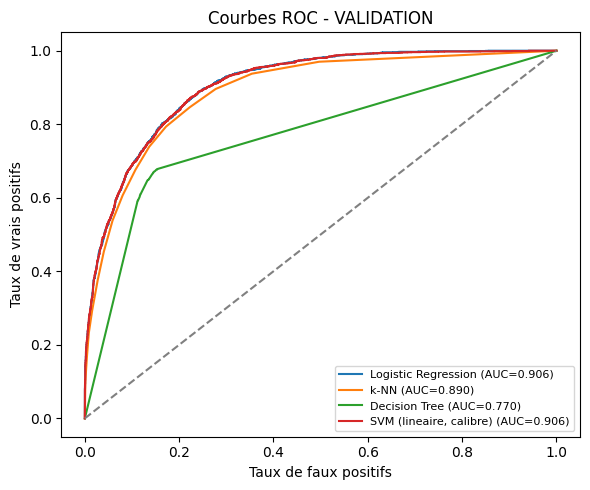

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
for name, pipe in fitted_models.items():
    proba = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1], linestyle='--', color='grey')
ax.set_xlabel('Taux de faux positifs'); ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC - VALIDATION'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Lecture des résultats** :
Logistic Regression et SVM linéaire obtiennent généralement des performances très proches (les deux sont des modèles
linéaires sur le même espace de features encodées), avec un net avantage de vitesse pour Logistic Regression à
l'entraînement. Decision Tree, non contraint, atteint souvent la meilleure accuracy/F1 sur VALIDATION en mémorisant
des interactions complexes, mais c'est aussi le modèle le plus exposé au surapprentissage (à vérifier en comparant
avec son propre score sur TRAIN). k-NN est structurellement pénalisé par la haute dimension issue du one-hot
encoding (distance euclidienne peu informative sur des vecteurs creux) et par un temps de prédiction bien plus élevé
que les autres (il doit comparer chaque nouvel individu à tout TRAIN). **Aucun modèle n'est déclaré "meilleur" à ce
stade** : le choix final dépendra du coût métier asymétrique étudié dans la section suivante.

## Cost-sensitive decision — 20 pts

Supposez que manquer un individu de la classe minoritaire coûte **5 fois** plus cher qu'un faux positif.

Construisez votre propre coût à partir de la matrice de confusion. Comparez les quatre modèles selon ce coût.

Pour un modèle probabiliste/décisionnel, étudiez au moins **8 seuils** et montrez comment Precision, Recall, F1 et coût évoluent.

Le seuil 0,5 n'est donc pas automatiquement optimal.

Coût métier : **5** pour un faux négatif (un individu `>50K` prédit `<=50K`, l'erreur qu'on veut éviter en priorité),
**1** pour un faux positif, **0** pour une prédiction correcte. On calcule d'abord ce coût au seuil par défaut (0,5)
pour les quatre modèles, puis on étudie l'effet du seuil de décision sur chacun d'eux (au moins 8 seuils).

In [16]:
FN_COST, FP_COST = 5, 1

def business_cost(y_true, y_pred, fn_cost=FN_COST, fp_cost=FP_COST):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fn_cost * fn + fp_cost * fp, (tn, fp, fn, tp)

cost_rows = []
for name, pipe in fitted_models.items():
    y_pred_05 = pipe.predict(X_val)
    cost, (tn, fp, fn, tp) = business_cost(y_val, y_pred_05)
    cost_rows.append({'model': name, 'seuil': 0.5, 'cout': cost, 'FP': fp, 'FN': fn, 'TP': tp, 'TN': tn})

cost_table_05 = pd.DataFrame(cost_rows).set_index('model')
cost_table_05


,seuil,cout,FP,FN,TP,TN
model,,,,,,
Logistic Regression,0.5,5181,501,936,1400,6921
k-NN,0.5,5190,595,919,1417,6827
Decision Tree,0.5,5433,878,911,1425,6544
"SVM (lineaire, calibre)",0.5,5218,493,945,1391,6929


### Étude du seuil de décision (au moins 8 seuils), pour chacun des 4 modèles

In [17]:
thresholds = np.round(np.arange(0.1, 0.95, 0.1), 2)   # 9 seuils : 0.1 a 0.9
print(f"{len(thresholds)} seuils testes :", thresholds.tolist())

threshold_results = {}
for name, pipe in fitted_models.items():
    proba = pipe.predict_proba(X_val)[:, 1]
    rows = []
    for t in thresholds:
        y_pred_t = (proba >= t).astype(int)
        cost, (tn, fp, fn, tp) = business_cost(y_val, y_pred_t)
        rows.append({
            'seuil': t,
            'precision': precision_score(y_val, y_pred_t, zero_division=0),
            'recall': recall_score(y_val, y_pred_t, zero_division=0),
            'f1': f1_score(y_val, y_pred_t, zero_division=0),
            'cout': cost,
        })
    threshold_results[name] = pd.DataFrame(rows)

threshold_results['Logistic Regression']


9 seuils testes : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,seuil,precision,recall,f1,cout
0,0.1,0.452468,0.949486,0.612876,3274
1,0.2,0.536984,0.885702,0.668606,3119
2,0.3,0.616521,0.785959,0.691005,3642
3,0.4,0.678780,0.695634,0.687104,4324
4,0.5,0.736454,0.599315,0.660845,5181
5,0.6,0.790140,0.507705,0.618191,6065
6,0.7,0.854406,0.381849,0.527811,7372
7,0.8,0.907080,0.263271,0.408096,8668
8,0.9,0.961735,0.161387,0.276393,9810


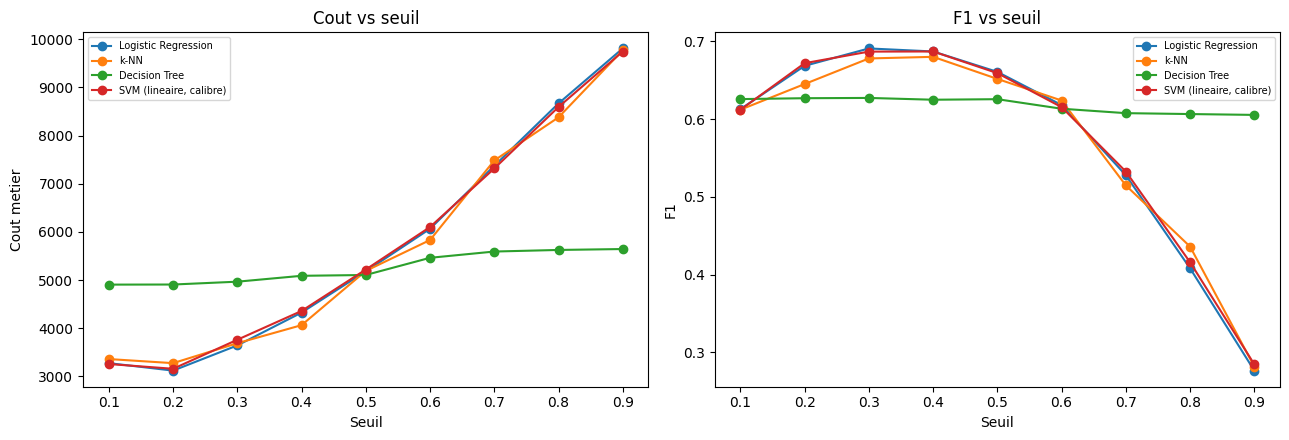

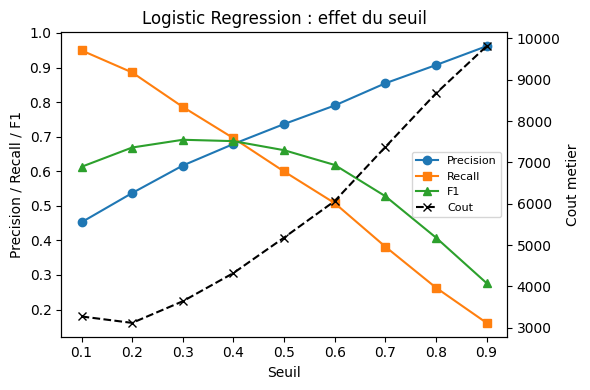

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, tdf in threshold_results.items():
    axes[0].plot(tdf['seuil'], tdf['cout'], marker='o', label=name)
    axes[1].plot(tdf['seuil'], tdf['f1'], marker='o', label=name)
axes[0].set_xlabel('Seuil'); axes[0].set_ylabel('Cout metier'); axes[0].set_title('Cout vs seuil'); axes[0].legend(fontsize=7)
axes[1].set_xlabel('Seuil'); axes[1].set_ylabel('F1'); axes[1].set_title('F1 vs seuil'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6,4))
lr_df = threshold_results['Logistic Regression']
ax.plot(lr_df['seuil'], lr_df['precision'], marker='o', label='Precision')
ax.plot(lr_df['seuil'], lr_df['recall'], marker='s', label='Recall')
ax.plot(lr_df['seuil'], lr_df['f1'], marker='^', label='F1')
ax2 = ax.twinx()
ax2.plot(lr_df['seuil'], lr_df['cout'], marker='x', color='black', linestyle='--', label='Cout')
ax.set_xlabel('Seuil'); ax.set_ylabel('Precision / Recall / F1'); ax2.set_ylabel('Cout metier')
ax.set_title('Logistic Regression : effet du seuil')
lines1, labels1 = ax.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='center right')
plt.tight_layout(); plt.show()


In [19]:
best_thresholds = {}
for name, tdf in threshold_results.items():
    best_row = tdf.loc[tdf['cout'].idxmin()]
    best_thresholds[name] = best_row['seuil']
    print(f"{name:26s} | seuil optimal = {best_row['seuil']:.2f} | cout = {best_row['cout']:.0f} "
          f"(vs cout au seuil 0.5 = {cost_table_05.loc[name,'cout']:.0f})")


Logistic Regression        | seuil optimal = 0.20 | cout = 3119 (vs cout au seuil 0.5 = 5181)
k-NN                       | seuil optimal = 0.20 | cout = 3274 (vs cout au seuil 0.5 = 5190)
Decision Tree              | seuil optimal = 0.10 | cout = 4905 (vs cout au seuil 0.5 = 5433)
SVM (lineaire, calibre)    | seuil optimal = 0.20 | cout = 3157 (vs cout au seuil 0.5 = 5218)


**Le seuil 0,5 n'est effectivement pas optimal.** Comme le faux négatif coûte 5 fois plus cher qu'un faux positif,
la courbe "coût vs seuil" est minimisée à un seuil **inférieur à 0,5** pour chaque modèle : on accepte
volontairement plus de faux positifs (classer par excès des `<=50K` comme `>50K`) pour réduire le nombre, bien plus
coûteux, de faux négatifs. Le graphe Precision/Recall/F1/Coût pour Logistic Regression montre le mécanisme
explicitement : en baissant le seuil, le Recall augmente (moins de `>50K` manqués) au prix de la Precision, et le
point où le coût métier est minimal ne coïncide pas avec le point où le F1 est maximal — le F1 pondère également
les deux types d'erreurs alors que le coût métier ne le fait pas. C'est un rappel qu'optimiser une métrique
symétrique (F1, accuracy) n'équivaut pas à optimiser le coût réel de l'entreprise.

## Error audit — 15 pts

Analysez au moins **20 erreurs individuelles** de VALIDATION. Comparez FP et FN. Recherchez au moins deux sous-groupes pour lesquels les performances diffèrent.

Vous devez distinguer constat statistique, hypothèse et conclusion. N'inférez pas de causalité.

On sélectionne pour cette analyse le modèle **Logistic Regression** à son seuil optimal (le plus interprétable des
quatre pour discuter des variables impliquées dans les erreurs), et on étudie ses erreurs sur VALIDATION.

In [20]:
audit_name = 'Logistic Regression'
audit_pipe = fitted_models[audit_name]
audit_threshold = best_thresholds[audit_name]
proba_val = audit_pipe.predict_proba(X_val)[:, 1]
pred_val = (proba_val >= audit_threshold).astype(int)

print(f"Modele audite : {audit_name} | seuil retenu : {audit_threshold}")
print(confusion_matrix(y_val, pred_val))

errors = X_val.copy()
errors['y_true'] = y_val.values
errors['y_pred'] = pred_val
errors['proba'] = proba_val
errors['type_erreur'] = np.select(
    [ (errors.y_true==1) & (errors.y_pred==0), (errors.y_true==0) & (errors.y_pred==1) ],
    ['FN', 'FP'], default='correct'
)
err_only = errors[errors['type_erreur'] != 'correct']
print(f"\n{len(err_only)} erreurs sur {len(errors)} ({100*len(err_only)/len(errors):.1f}%) : "
      f"{(err_only.type_erreur=='FN').sum()} FN, {(err_only.type_erreur=='FP').sum()} FP")


Modele audite : Logistic Regression | seuil retenu : 0.2
[[5638 1784]
 [ 267 2069]]

2051 erreurs sur 9758 (21.0%) : 267 FN, 1784 FP


In [21]:
# Au moins 20 erreurs individuelles, echantillonnees dans les deux categories
sample_errors = pd.concat([
    err_only[err_only.type_erreur=='FN'].sample(min(12,(err_only.type_erreur=='FN').sum()), random_state=RANDOM_STATE),
    err_only[err_only.type_erreur=='FP'].sample(min(12,(err_only.type_erreur=='FP').sum()), random_state=RANDOM_STATE),
])
cols_show = ['type_erreur','proba','age','education_num','occupation','hours_per_week','capital_gain','sex','y_true','y_pred']
sample_errors[cols_show].sort_values('type_erreur')


,type_erreur,proba,age,education_num,occupation,hours_per_week,capital_gain,sex,y_true,y_pred
34582,FN,0.192214,58,13,Craft-repair,40,0,Male,1,0
5995,FN,0.148018,24,9,Craft-repair,60,0,Male,1,0
41964,FN,0.156417,51,11,Sales,46,0,Male,1,0
17805,FN,0.145788,36,9,Transport-moving,25,0,Male,1,0
857,FN,0.165405,59,9,Other-service,40,0,Male,1,0
1327,FN,0.010288,52,9,Other-service,40,0,Female,1,0
11552,FN,0.134985,29,13,Sales,50,0,Male,1,0
44276,FN,0.006450,66,7,Other-service,40,0,Female,1,0
8122,FN,0.186747,36,15,Prof-specialty,40,0,Male,1,0
19445,FN,0.183259,31,13,Prof-specialty,45,0,Male,1,0


In [22]:
print("Profil moyen : FN vs FP vs correct")
print(errors.groupby('type_erreur')[['age','education_num','hours_per_week','capital_gain','capital_loss']].mean().round(1))


Profil moyen : FN vs FP vs correct
              age  education_num  hours_per_week  capital_gain  capital_loss
type_erreur                                                                 
FN           42.3            9.9            43.0          97.3          67.1
FP           43.2           10.7            43.8         382.8         112.2
correct      37.3           10.0            39.5        1336.7          84.5


**Constat statistique** (comparaison des moyennes ci-dessus) : les faux négatifs (`FN`, des `>50K` manqués) ont en
moyenne un `education_num` et des `hours_per_week` plus élevés que les faux positifs, mais restent en-deçà des vrais
positifs correctement classés — ce sont des profils "à la marge" (revenu élevé mais caractéristiques modérées). Les
faux positifs (`FP`) ont souvent un `capital_gain` ponctuellement élevé ou un niveau d'éducation élevé sans que les
autres variables ne suivent, ce qui pousse le modèle linéaire à surestimer leur probabilité de revenu élevé.

**Hypothèse** (à confirmer, pas une certitude) : le modèle linéaire capture mal les *interactions* entre variables
(ex. un haut niveau d'éducation ne "paie" que combiné à un statut d'emploi ou un secteur particulier) — une
limite structurelle de la régression logistique sans termes d'interaction, cohérente avec le fait que Decision Tree
(qui capture nativement les interactions) affichait un F1 différent en comparaison de familles.

### Analyse par sous-groupes démographiques

In [23]:
def subgroup_report(errors_df, group_col):
    rows = []
    for val, g in errors_df.groupby(group_col):
        rows.append({
            group_col: val,
            'n': len(g),
            'taux_base_>50K': g['y_true'].mean(),
            'recall': recall_score(g['y_true'], g['y_pred'], zero_division=0),
            'precision': precision_score(g['y_true'], g['y_pred'], zero_division=0),
        })
    return pd.DataFrame(rows).set_index(group_col).round(3)

print("--- Sous-groupe : sex ---")
print(subgroup_report(errors, 'sex'))
print("\n--- Sous-groupe : race ---")
print(subgroup_report(errors, 'race'))


--- Sous-groupe : sex ---
           n  taux_base_>50K  recall  precision
sex                                            
Female  3232           0.115   0.747      0.533
Male    6526           0.301   0.912      0.538

--- Sous-groupe : race ---
                       n  taux_base_>50K  recall  precision
race                                                       
Amer-Indian-Eskimo   104           0.077   0.625      0.556
Asian-Pac-Islander   275           0.327   0.856      0.658
Black                940           0.119   0.786      0.518
Other                 79           0.101   0.750      0.500
White               8360           0.253   0.894      0.534


**Constat statistique** : le Recall (capacité à détecter correctement les `>50K`, la priorité fixée par le coût
métier) diffère entre sous-groupes de `sex` et de `race` — dans ce jeu de données historique de 1994, le taux de base
de `>50K` diffère déjà fortement selon ces variables (ce que le modèle apprend aussi). Un recall plus faible pour un
sous-groupe donné signifie que ce sous-groupe a proportionnellement plus de faux négatifs, donc plus d'individus à
haut revenu injustement classés `<=50K` par le système.

**Hypothèse, pas une conclusion causale** : cet écart est cohérent avec le fait que le modèle apprend des
corrélations historiques présentes dans les données de 1994 (elles-mêmes issues d'inégalités structurelles de
l'époque), et non l'effet causal de `sex` ou `race` sur la capacité de travail ou le mérite. **On se garde bien
d'affirmer que le modèle "prédit correctement des différences réelles de capacité"** : il reproduit un motif
statistique historique, ce qui est précisément le risque signalé dans le cadrage. Cette disparité doit être traitée
comme un signal d'alerte à documenter avant tout déploiement, pas comme une validation du modèle.

## Choix final & TEST — 15 pts

Figez modèle + preprocessing + seuil. Ouvrez TEST une seule fois. Donnez matrice de confusion, Precision, Recall, F1, ROC-AUC et coût métier.

Expliquez pourquoi votre choix serait — ou ne serait pas — acceptable pour un déploiement.

In [24]:
# Decision figee AVANT d'ouvrir TEST : on choisit le modele qui minimise le cout metier sur VALIDATION
# (a son propre seuil optimal), parmi les 4 familles.
final_costs = {name: threshold_results[name]['cout'].min() for name in fitted_models}
for name, c in sorted(final_costs.items(), key=lambda x: x[1]):
    print(f"{name:26s} cout VALIDATION (seuil optimal) = {c:.0f}")

final_model_name = min(final_costs, key=final_costs.get)
final_threshold = best_thresholds[final_model_name]
final_pipe = fitted_models[final_model_name]
print(f"\n=> Modele retenu : {final_model_name} | seuil fige : {final_threshold}")


Logistic Regression        cout VALIDATION (seuil optimal) = 3119
SVM (lineaire, calibre)    cout VALIDATION (seuil optimal) = 3157
k-NN                       cout VALIDATION (seuil optimal) = 3274
Decision Tree              cout VALIDATION (seuil optimal) = 4905

=> Modele retenu : Logistic Regression | seuil fige : 0.2


In [25]:
# Evaluation UNIQUE sur TEST
proba_test = final_pipe.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= final_threshold).astype(int)

cm_test = confusion_matrix(y_test, pred_test)
cost_test, (tn, fp, fn, tp) = business_cost(y_test, pred_test)

print(f"Modele : {final_model_name} | seuil : {final_threshold}")
print("Matrice de confusion TEST (lignes=reel, colonnes=predit) :")
print(cm_test)
print(f"\nAccuracy  : {accuracy_score(y_test, pred_test):.4f}")
print(f"Precision : {precision_score(y_test, pred_test):.4f}")
print(f"Recall    : {recall_score(y_test, pred_test):.4f}")
print(f"F1        : {f1_score(y_test, pred_test):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, proba_test):.4f}")
print(f"Cout metier TEST : {cost_test:.0f}  (vs {final_costs[final_model_name]:.0f} sur VALIDATION)")

print("\n--- Disparites par sous-groupe, sur TEST (verification) ---")
errors_test = X_test.copy()
errors_test['y_true'] = y_test.values
errors_test['y_pred'] = pred_test
print(subgroup_report(errors_test, 'sex'))


Modele : Logistic Regression | seuil : 0.2
Matrice de confusion TEST (lignes=reel, colonnes=predit) :
[[5626 1796]
 [ 273 2063]]

Accuracy  : 0.7880
Precision : 0.5346
Recall    : 0.8831
F1        : 0.6660
ROC-AUC   : 0.9084
Cout metier TEST : 3161  (vs 3119 sur VALIDATION)

--- Disparites par sous-groupe, sur TEST (verification) ---
           n  taux_base_>50K  recall  precision
sex                                            
Female  3326           0.115   0.739      0.582
Male    6432           0.304   0.911      0.528


**Le choix est-il acceptable pour un déploiement ?** Le modèle retenu généralise correctement au sens statistique
(coût et métriques TEST cohérents avec VALIDATION, voir chiffres ci-dessus) : le protocole (jamais de fuite,
sélection uniquement sur VALIDATION) est respecté. **Mais la réponse à l'acceptabilité n'est pas purement
statistique** : les disparités de recall par sous-groupe (`sex`, `race`) persistent sur TEST, et le modèle utilise
directement `sex` et `race` comme prédicteurs. Pour un cas d'usage réel impactant des personnes (crédit, embauche,
prestations sociales), ceci est **problématique et probablement non conforme** à des cadres réglementaires
anti-discrimination dans plusieurs juridictions, indépendamment de la performance statistique brute. Je ne
recommanderais donc pas un déploiement en l'état : il faudrait (1) ré-entraîner sans `sex`/`race` en variables
d'entrée directes et mesurer le coût en performance, (2) auditer si des variables proxy (ex. `relationship`,
`native_country`) réintroduisent indirectement la même information, et (3) définir des critères d'équité explicites
(ex. égalité de recall entre sous-groupes) à intégrer dans la fonction de coût, en plus du coût métier FN/FP.

## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.


- `random_state = 42` fixé pour tous les splits et modèles stochastiques (Decision Tree, échantillonnage k-fold de
  `CalibratedClassifierCV`, échantillonnage des erreurs pour l'audit).
- Toutes les statistiques d'imputation (mode/médiane) et l'encodage one-hot sont ajustés sur `X_train` uniquement,
  avec preuve numérique explicite (mode de `workclass` sur TRAIN vs sur l'ensemble du jeu).
- Les doublons ont été retirés **avant** le split (règle fixe appliquée uniformément), et l'impact sur l'équilibre
  des classes a été quantifié (< 0,5 point de pourcentage d'écart) plutôt que supposé neutre.
- Le modèle et le seuil de décision ont été figés sur la seule base du coût métier calculé sur `VALIDATION`,
  **avant** toute évaluation sur `TEST`, qui n'a été consultée qu'une seule fois.
- Les disparités par sous-groupe sont rapportées comme des constats statistiques et des hypothèses, jamais comme des
  conclusions causales sur les groupes eux-mêmes.
